In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import get_scorer
from tqdm import tqdm   # <- progress bar
import os
from sklearn.inspection import permutation_importance


In [2]:
#pip install tqdm

In [3]:
def train_perm_importance_gb(
    df, target,
    test_size=0.3,
    random_state=42,
    scoring="roc_auc",
    n_repeats=10
):
    """
    Fast, self-contained permutation-importance workflow using a light GradientBoostingClassifier.
    - Uses ONLY numeric features (keeps it quick; avoids encoding).
    - Median-imputes missing numerics.
    - Trains a small GB model.
    - Computes permutation importance on the held-out test set.

    Returns:
        df_imp  : DataFrame [rank, feature, importance_mean, importance_std]
        result  : sklearn permutation_importance result (for advanced plotting)
        pipe    : fitted sklearn Pipeline (imputer + model)
        X_test  : test features (DataFrame, post column selection)
        y_test  : test targets (Series)
    """
    # Split features / target
    y = df[target]
    X = df.drop(columns=[target])

    # Keep only numeric columns for speed & simplicity
    num_cols = X.select_dtypes(include=[np.number]).columns
    X = X[num_cols].copy()

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y if y.nunique() == 2 else None
    )

    # Lightweight Gradient Boosting model
    pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(
            n_estimators=120,        # small, quick
            learning_rate=0.08,
            max_depth=3,
            subsample=0.9,
            random_state=random_state
        ))
    ])

    # Train
    pipe.fit(X_train, y_train)

    # Permutation importance on held-out test set
    result = permutation_importance(
        pipe, X_test, y_test,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=None
    )

    # Rank table
    df_imp = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)
    df_imp["rank"] = np.arange(1, len(df_imp) + 1)
    df_imp = df_imp[["rank", "feature", "importance_mean", "importance_std"]]

    return df_imp, result

# def train_perm_importance_gb(
#     df, target,
#     test_size=0.3,
#     random_state=42,
#     scoring="roc_auc",
#     n_repeats=10
# ):
    

# """
#     Fast, self-contained permutation-importance workflow using a light GradientBoostingClassifier.
#     - Uses ONLY numeric features (keeps it quick; avoids encoding).
#     - Median-imputes missing numerics.
#     - Trains a small GB model.
#     - Computes permutation importance on the held-out test set.
#     Returns:
#         df_imp  : DataFrame [rank, feature, importance_mean, importance_std]
#         result  : sklearn permutation_importance result (for advanced plotting)
#         pipe    : fitted sklearn Pipeline (imputer + model)
#         X_test  : test features (DataFrame, post column selection)
#         y_test  : test targets (Series)
# """

#     y = df[target]
#     X = df.drop(columns=[target])

#     # Keep only numeric columns
#     num_cols = X.select_dtypes(include=[np.number]).columns
#     X = X[num_cols].copy()

#     X_train, X_test, y_train, y_test = train_test_split(
#         X, y, test_size=test_size, random_state=random_state,
#         stratify=y if y.nunique() == 2 else None
#     )

#     pipe = Pipeline(steps=[
#         ("imputer", SimpleImputer(strategy="median")),
#         ("model", GradientBoostingClassifier(
#             n_estimators=120,
#             learning_rate=0.08,
#             max_depth=3,
#             subsample=0.9,
#             random_state=random_state
#         ))
#     ])

#     pipe.fit(X_train, y_train)

#     # Custom permutation importance with progress bar
#     scorer = get_scorer(scoring)
#     baseline = scorer(pipe, X_test, y_test)

#     rng = np.random.RandomState(random_state)
#     importances = np.zeros((X_test.shape[1], n_repeats))

#     for n in tqdm(range(n_repeats), desc="Permutation Progress"):
#         for col_idx, col in enumerate(X_test.columns):
#             X_permuted = X_test.copy()
#             X_permuted[col] = rng.permutation(X_permuted[col].values)
#             score = scorer(pipe, X_permuted, y_test)
#             importances[col_idx, n] = baseline - score

#     means = importances.mean(axis=1)
#     stds = importances.std(axis=1)

#     df_imp = pd.DataFrame({
#         "feature": X_test.columns,
#         "importance_mean": means,
#         "importance_std": stds
#     }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

#     df_imp["rank"] = np.arange(1, len(df_imp) + 1)
#     df_imp = df_imp[["rank", "feature", "importance_mean", "importance_std"]]

#     return df_imp, importances, pipe, X_test, y_test




def plot_perm_importance_bar(df_imp, top_n=20, title="Permutation Importance (top features)"):
    """
    Horizontal bar chart of permutation importance with error bars (±1 std).
    """
    d = df_imp.head(top_n).iloc[::-1]  # reverse so most important at top
    plt.figure(figsize=(10, 6))
    plt.barh(d["feature"], d["importance_mean"], xerr=d["importance_std"], align="center")
    plt.xlabel("Decrease in score (mean ± std)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# def plot_perm_importance_box(result, feature_names, top_n=20, title="Permutation Importance (boxplot)"):
#     """
#     Boxplot style similar to the sklearn example:
#     https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html
#     """
#     means = result.importances_mean
#     idx_sorted = np.argsort(means)[::-1][:top_n]
#     data = result.importances[idx_sorted].T  # shape: (n_repeats, n_features_selected)
#     labels = np.array(feature_names)[idx_sorted]

#     plt.figure(figsize=(10, 6))
#     plt.boxplot(data, vert=False, labels=labels)
#     plt.axvline(0, linestyle="--", color="gray", linewidth=1)
#     plt.xlabel("Decrease in score when permuted")
#     plt.title(title)
#     plt.tight_layout()
#     plt.show()


def plot_perm_importance_box(importances_or_result, feature_names, top_n=20,
                             title="Permutation Importance (boxplot)"):
    """
    Accepts either:
      - sklearn PermutationImportanceResult (has .importances and .importances_mean), or
      - raw ndarray (n_features, n_repeats) as returned by the custom progress loop.
    """
    # Detect type
    if hasattr(importances_or_result, "importances_mean"):  # sklearn object
        importances = importances_or_result.importances      # (n_features, n_repeats)
        means = importances_or_result.importances_mean       # (n_features,)
    else:  # numpy array from our custom function
        importances = np.asarray(importances_or_result)      # (n_features, n_repeats)
        means = importances.mean(axis=1)

    # get top_n indices
    idx_sorted = np.argsort(means)[::-1][:top_n]
    data = importances[idx_sorted].T          # (n_repeats, top_n)
    labels = np.array(feature_names)[idx_sorted]

    # plot
    plt.figure(figsize=(10, 6))
    plt.boxplot(data, vert=False, labels=labels)
    plt.axvline(0, linestyle="--", color="gray", linewidth=1)
    plt.xlabel("Decrease in score when permuted")
    plt.title(title)
    plt.tight_layout()
    plt.show()



def save_file(df, output_file = "Modulo1633_REC41_2024_fil_clear.csv"):

    # File name only

    # Go one level up from the current working directory
    base_dir = os.path.dirname(os.getcwd())   # gives "c:\\Users\\linoc\\OneDrive\\Encoder\\03_partos"
    output_dir = os.path.join(base_dir, "data\\interim")

    #Full path
    output_path = os.path.join(output_dir, output_file)

    # Save DataFrame
    df.to_csv(output_path, index=False, encoding="utf-8-sig")


## Modulo1633_REC41_2024_fil_clear

In [4]:
base_dir = os.path.dirname(os.getcwd())   # → c:\Users\linoc\OneDrive\Encoder\03_partos
base_dir

'c:\\Users\\linoc\\OneDrive\\Encoder\\03_partos\\02_scripts\\Premature_model'

In [5]:
# Build base directory (go up one level from current /02_scripts)
base_dir = os.path.dirname(os.getcwd())   # → c:\Users\linoc\OneDrive\Encoder\03_partos

csv_path_target_final = os.path.join(base_dir,"data\\interim", "target_final.csv")
csv_path_Modulo1633_REC41_2024_fil_clear = os.path.join(base_dir,"data\\interim", "Modulo1633_REC41_2024_fil_clear.csv")


# Load the dataset
target_final = pd.read_csv(csv_path_target_final,usecols = ['CASEID','premature_flag'], low_memory=False)
Modulo1633_REC41_2024_fil_clear = pd.read_csv(csv_path_Modulo1633_REC41_2024_fil_clear, low_memory=False)

target_final.shape, Modulo1633_REC41_2024_fil_clear.shape

((18335, 2), (16983, 463))

In [6]:
target_final['premature_flag'].value_counts(1)

premature_flag
0    0.807254
1    0.192746
Name: proportion, dtype: float64

In [7]:
target_final.shape, target_final.CASEID.nunique()

((18335, 2), 18335)

In [8]:
Modulo1633_REC41_2024_fil_clear.info(verbose = True,show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16983 entries, 0 to 16982
Data columns (total 463 columns):
 #    Column          Non-Null Count  Dtype  
---   ------          --------------  -----  
 0    premature_flag  16983 non-null  int64  
 1    M2A             14982 non-null  float64
 2    M2B             14982 non-null  float64
 3    M2C             14982 non-null  float64
 4    M2D             14982 non-null  float64
 5    M2E             14982 non-null  float64
 6    M2G             14982 non-null  float64
 7    M2K             14982 non-null  float64
 8    M2N             14982 non-null  float64
 9    M3A             16983 non-null  int64  
 10   M3B             16983 non-null  int64  
 11   M3C             16983 non-null  int64  
 12   M3D             16983 non-null  int64  
 13   M3E             16983 non-null  int64  
 14   M3G             16983 non-null  int64  
 15   M3H             16983 non-null  int64  
 16   M3K             16983 non-null  int64  
 17   M3N       

In [9]:
#Modulo1633_REC41_2024_fil_clear = Modulo1633_REC41_2024_fil_clear.merge(target_final, how= 'left', on ='CASEID')
Modulo1633_REC41_2024_fil_clear = Modulo1633_REC41_2024_fil_clear.dropna()
Modulo1633_REC41_2024_fil_clear.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
Index: 4340 entries, 6 to 16982
Data columns (total 463 columns):
 #    Column          Non-Null Count  Dtype  
---   ------          --------------  -----  
 0    premature_flag  4340 non-null   int64  
 1    M2A             4340 non-null   float64
 2    M2B             4340 non-null   float64
 3    M2C             4340 non-null   float64
 4    M2D             4340 non-null   float64
 5    M2E             4340 non-null   float64
 6    M2G             4340 non-null   float64
 7    M2K             4340 non-null   float64
 8    M2N             4340 non-null   float64
 9    M3A             4340 non-null   int64  
 10   M3B             4340 non-null   int64  
 11   M3C             4340 non-null   int64  
 12   M3D             4340 non-null   int64  
 13   M3E             4340 non-null   int64  
 14   M3G             4340 non-null   int64  
 15   M3H             4340 non-null   int64  
 16   M3K             4340 non-null   int64  
 17   M3N             

In [11]:
df_imp, result = train_perm_importance_gb(
    Modulo1633_REC41_2024_fil_clear, target="premature_flag", scoring="roc_auc", n_repeats=15
)

In [12]:
df_imp

,rank,feature,importance_mean,importance_std
0,1,M14,0.187659,0.012693
1,2,M13,0.057777,0.004860
2,3,M17,0.023814,0.005710
3,4,M7,0.003734,0.003851
4,5,M3A,0.003731,0.001711
5,6,M57I,0.002918,0.001436
6,7,M3H,0.001131,0.000937
7,8,M57O,0.001060,0.001311
8,9,M57G,0.000928,0.001015
9,10,M3B,0.000589,0.000561


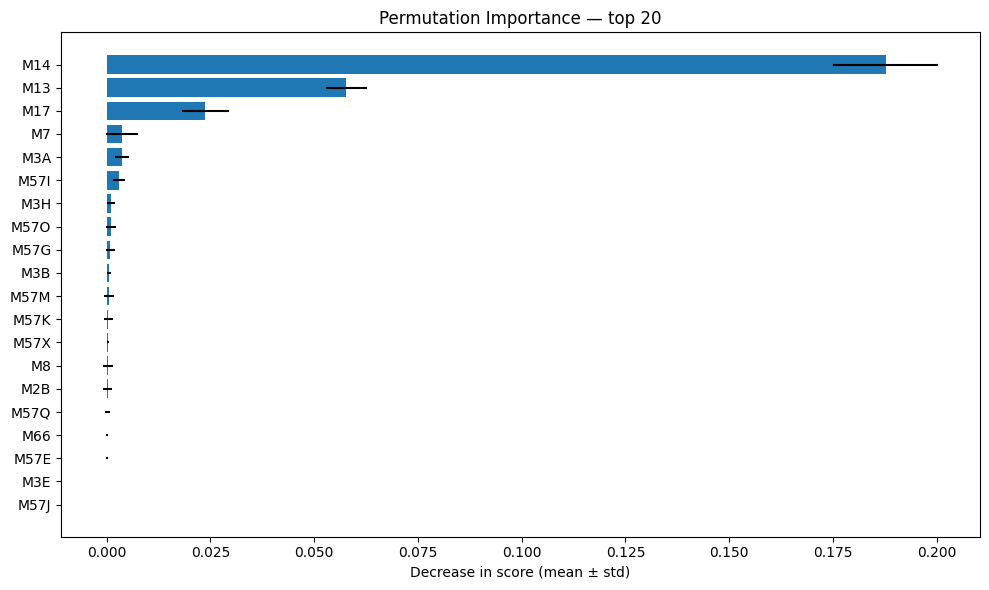

In [10]:
plot_perm_importance_bar(df_imp, top_n=20, title="Permutation Importance — top 20")

In [13]:
save_file(df_imp, output_file = "RANK_Modulo1633_REC41_2024_fil_clear.csv")

In [9]:
# # Or boxplot style (uses the raw importance samples)
# plot_perm_importance_box(result, feature_names=X_test.columns, top_n=20,
#                          title="Permutation Importance (boxplot) — top 20")

## Modulo1633_REC94_2024_fil_clear

In [13]:
csv_path_Modulo1633_REC94_2024_fil_clear = os.path.join(base_dir,"data\\interim", "Modulo1633_REC94_2024_fil_clear.csv")
Modulo1633_REC94_2024_fil_clear = pd.read_csv(csv_path_Modulo1633_REC94_2024_fil_clear, low_memory=False)

#Modulo1633_REC94_2024_fil_clear = Modulo1633_REC94_2024_fil_clear.merge(target_final, how= 'left', on ='CASEID')
Modulo1633_REC94_2024_fil_clear = Modulo1633_REC94_2024_fil_clear.dropna()
Modulo1633_REC94_2024_fil_clear.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16983 entries, 0 to 16982
Data columns (total 275 columns):
 #    Column          Non-Null Count  Dtype  
---   ------          --------------  -----  
 0    IDX94_x         16983 non-null  float64
 1    S411EA          16983 non-null  float64
 2    S411BA          16983 non-null  float64
 3    S411DA          16983 non-null  float64
 4    S422I           16983 non-null  float64
 5    S411CA          16983 non-null  float64
 6    IDX94_y         16983 non-null  float64
 7    premature_flag  16983 non-null  int64  
 8    S413            16983 non-null  float64
 9    S426E           16983 non-null  float64
 10   S426GA          16983 non-null  float64
 11   S426GB          16983 non-null  float64
 12   S426GC          16983 non-null  float64
 13   S426GD          16983 non-null  float64
 14   S426GE          16983 non-null  float64
 15   S430D           16983 non-null  float64
 16   S427DA          16983 non-null  float64
 17   S427DB    

In [15]:
RANK_Modulo1633_REC94_2024_fil_clear, result_Modulo1633_REC94_2024_fil_clear, = train_perm_importance_gb(
    Modulo1633_REC94_2024_fil_clear, target="premature_flag", scoring="roc_auc", n_repeats=15
)

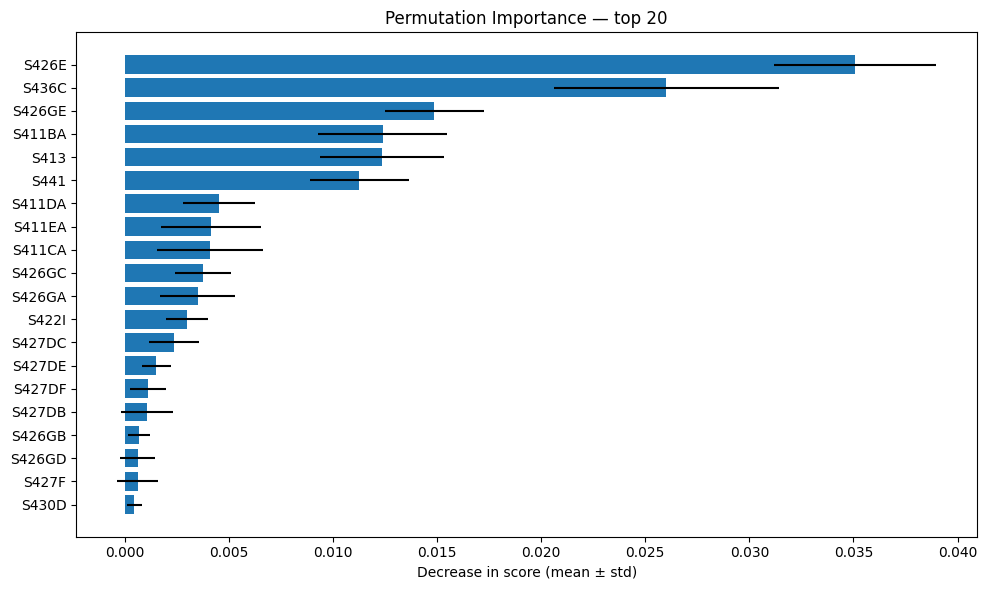

In [16]:
plot_perm_importance_bar(RANK_Modulo1633_REC94_2024_fil_clear, top_n=20, title="Permutation Importance — top 20")

In [17]:
save_file(RANK_Modulo1633_REC94_2024_fil_clear, output_file = "RANK_Modulo1633_REC94_2024_fil_clear.csv")

In [13]:
# # Or boxplot style (uses the raw importance samples)
# plot_perm_importance_box(result_Modulo1633_REC94_2024_fil_clear, feature_names=X_test.columns, top_n=20,
#                          title="Permutation Importance (boxplot) — top 20")

## Modulo1631_REC91_2024_M_clear

In [14]:
csv_path_Modulo1631_REC91_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1631_REC91_2024_M_clear.csv")
Modulo1631_REC91_2024_M_clear = pd.read_csv(csv_path_Modulo1631_REC91_2024_M_clear, low_memory=False)

Modulo1631_REC91_2024_M_clear.shape, Modulo1631_REC91_2024_M_clear.CASEID.nunique()

((37117, 132), 37117)

In [15]:
Modulo1631_REC91_2024_M_clear = Modulo1631_REC91_2024_M_clear.merge(target_final, how= 'left', on ='CASEID')
Modulo1631_REC91_2024_M_clear = Modulo1631_REC91_2024_M_clear.dropna()
Modulo1631_REC91_2024_M_clear.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
Index: 18335 entries, 0 to 37115
Data columns (total 133 columns):
 #    Column          Non-Null Count  Dtype  
---   ------          --------------  -----  
 0    ID1             18335 non-null  float64
 1    SREGION         18335 non-null  float64
 2    SSEMES          18335 non-null  float64
 3    SPROVIN         18335 non-null  float64
 4    SDISTRI         18335 non-null  float64
 5    S108N           18335 non-null  float64
 6    S108Y           18335 non-null  float64
 7    S119            18335 non-null  float64
 8    S119NA          18335 non-null  float64
 9    S119NB          18335 non-null  float64
 10   S119D           18335 non-null  float64
 11   S489C           18335 non-null  float64
 12   S489D           18335 non-null  float64
 13   S490            18335 non-null  float64
 14   S704N           18335 non-null  float64
 15   S704Y           18335 non-null  float64
 16   S802            18335 non-null  float64
 17   S802D          

In [22]:
RANK_Modulo1631_REC91_2024_M_clear,result_Modulo1631_REC91_2024_M_clear, = train_perm_importance_gb(
    Modulo1631_REC91_2024_M_clear, target="premature_flag", scoring="roc_auc", n_repeats=15
)

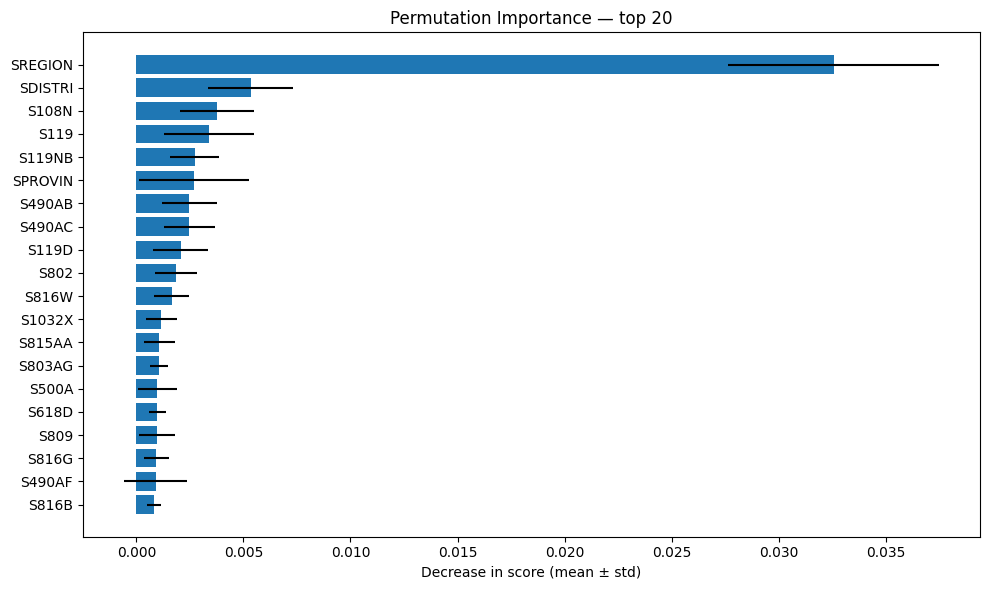

In [24]:
plot_perm_importance_bar(RANK_Modulo1631_REC91_2024_M_clear, top_n=20, title="Permutation Importance — top 20")

In [25]:
save_file(RANK_Modulo1631_REC91_2024_M_clear, output_file = "RANK_Modulo1631_REC91_2024_M_clear.csv")

## Modulo1632_RE223132_2024

In [26]:
csv_path_Modulo1632_RE223132_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1632_RE223132_2024_M_clear.csv")
Modulo1632_RE223132_2024_M_clear = pd.read_csv(csv_path_Modulo1632_RE223132_2024_M_clear, low_memory=False)
Modulo1632_RE223132_2024_M_clear.shape, Modulo1632_RE223132_2024_M_clear.CASEID.nunique()

((34252, 65), 34252)

In [27]:
Modulo1632_RE223132_2024_M_clear = Modulo1632_RE223132_2024_M_clear.merge(target_final, how= 'left', on ='CASEID')
Modulo1632_RE223132_2024_M_clear = Modulo1632_RE223132_2024_M_clear.dropna()
Modulo1632_RE223132_2024_M_clear.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
Index: 18335 entries, 0 to 34250
Data columns (total 66 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID1             18335 non-null  float64
 1   V201            18335 non-null  float64
 2   V202            18335 non-null  float64
 3   V203            18335 non-null  float64
 4   V204            18335 non-null  float64
 5   V205            18335 non-null  float64
 6   V206            18335 non-null  float64
 7   V207            18335 non-null  float64
 8   V208            18335 non-null  float64
 9   V209            18335 non-null  float64
 10  V210            18335 non-null  float64
 11  V211            18335 non-null  float64
 12  V212            18335 non-null  float64
 13  V215            18335 non-null  float64
 14  V217            18335 non-null  float64
 15  V218            18335 non-null  float64
 16  V219            18335 non-null  float64
 17  V220            18335 non-null  floa

In [28]:
RANK_Modulo1632_RE223132_2024_M_clear,result_Modulo1632_RE223132_2024_M_clear, = train_perm_importance_gb(
    Modulo1632_RE223132_2024_M_clear, target="premature_flag", scoring="roc_auc", n_repeats=15
)

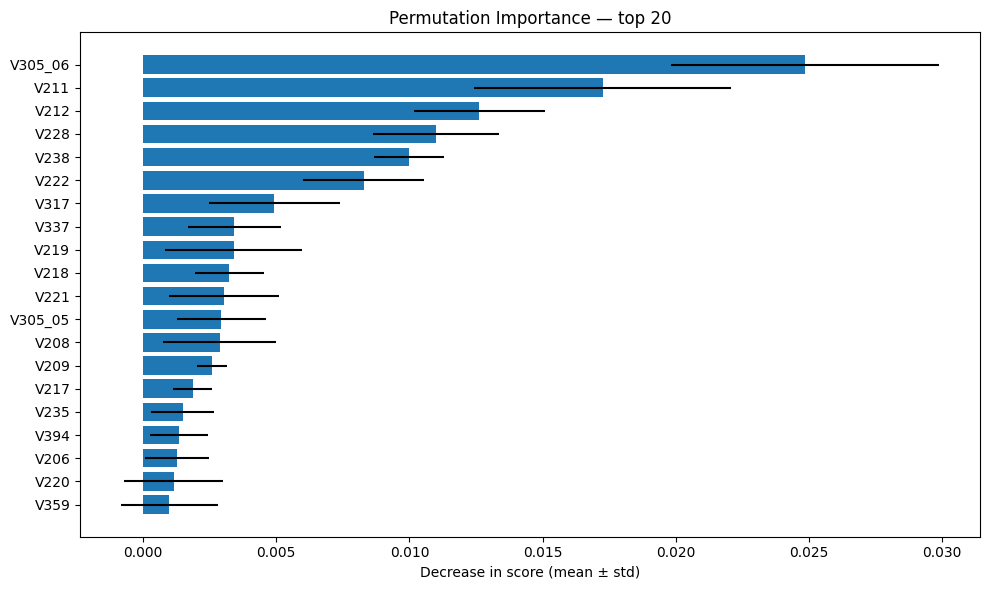

In [29]:
plot_perm_importance_bar(RANK_Modulo1632_RE223132_2024_M_clear, top_n=20, title="Permutation Importance — top 20")

In [30]:
save_file(RANK_Modulo1632_RE223132_2024_M_clear, output_file = "RANK_Modulo1632_RE223132_2024_M_clear.csv")

## Modulo1635_RE516171_2024

In [31]:
csv_path_Modulo1635_RE516171_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1635_RE516171_2024_M_clear.csv")
Modulo1635_RE516171_2024_M_clear = pd.read_csv(csv_path_Modulo1635_RE516171_2024_M_clear, low_memory=False)
Modulo1635_RE516171_2024_M_clear.shape, Modulo1635_RE516171_2024_M_clear.CASEID.nunique()

((34252, 63), 34252)

In [32]:
Modulo1635_RE516171_2024_M_clear = Modulo1635_RE516171_2024_M_clear.merge(target_final, how= 'left', on ='CASEID')
Modulo1635_RE516171_2024_M_clear = Modulo1635_RE516171_2024_M_clear.dropna()
Modulo1635_RE516171_2024_M_clear.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
Index: 18335 entries, 0 to 34250
Data columns (total 64 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID1             18335 non-null  float64
 1   V501            18335 non-null  float64
 2   V502            18335 non-null  float64
 3   V503            18335 non-null  float64
 4   V504            18335 non-null  float64
 5   V507            18335 non-null  float64
 6   V508            18335 non-null  float64
 7   V509            18335 non-null  float64
 8   V510            18335 non-null  float64
 9   V511            18335 non-null  float64
 10  V512            18335 non-null  float64
 11  V513            18335 non-null  float64
 12  V525            18335 non-null  float64
 13  V527            18335 non-null  float64
 14  V528            18335 non-null  float64
 15  V529            18335 non-null  float64
 16  V530            18335 non-null  float64
 17  V531            18335 non-null  floa

In [33]:
RANK_MModulo1635_RE516171_2024_M_clear,result_Modulo1635_RE516171_2024_M_clear, = train_perm_importance_gb(
    Modulo1635_RE516171_2024_M_clear, target="premature_flag", scoring="roc_auc", n_repeats=15
)

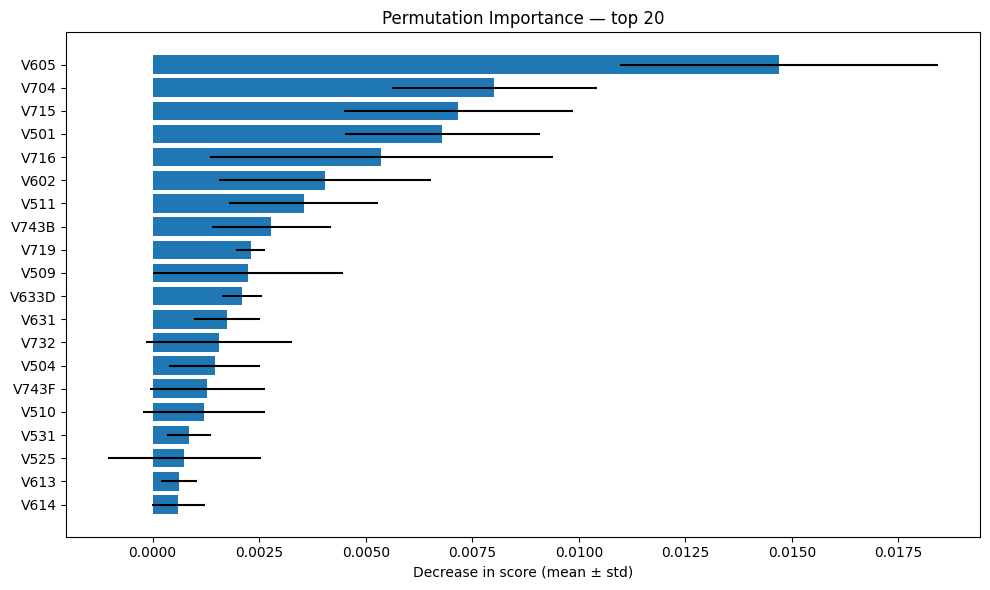

In [34]:
plot_perm_importance_bar(RANK_MModulo1635_RE516171_2024_M_clear, top_n=20, title="Permutation Importance — top 20")

In [35]:
save_file(RANK_MModulo1635_RE516171_2024_M_clear, output_file = "RANK_MModulo1635_RE516171_2024_M_clear.csv")

## Modulo1640_CSALUD01_2024

In [ ]:
csv_path_Modulo1640_CSALUD01_2024_M_clear = os.path.join(base_dir,"data\\interim", "Modulo1640_CSALUD01_2024_M_clear.csv")
Modulo1640_CSALUD01_2024_M_clear = pd.read_csv(csv_path_Modulo1640_CSALUD01_2024_M_clear, low_memory=False)
Modulo1640_CSALUD01_2024_M_clear.shape, Modulo1640_CSALUD01_2024_M_clear.HHID.nunique()

((34018, 153), 34018)

In [37]:
# Ensure CASEID is string
target_final["CASEID_9d"] = (
    target_final["CASEID"]
    .astype(str)     # convert to string
    .str.strip()     # remove extra spaces
    .str[:9]         # take first 9 characters
)

# If you want numeric again (preserves the 9 digits correctly)
target_final["CASEID_9d"] = (
    target_final["CASEID_9d"].astype(int))

target_final.head()

,CASEID,premature_flag,CASEID_9d
0,325503101 2,1,325503101
1,325504701 2,0,325504701
2,325505001 1,0,325505001
3,325508901 2,0,325508901
4,325509701 2,0,325509701


In [38]:
target_final.shape

(18335, 3)

In [39]:
Modulo1640_CSALUD01_2024_M_clear = Modulo1640_CSALUD01_2024_M_clear.merge(target_final, right_on= 'CASEID_9d', left_on  = 'HHID', how = 'left')
Modulo1640_CSALUD01_2024_M_clear = Modulo1640_CSALUD01_2024_M_clear.dropna()
Modulo1640_CSALUD01_2024_M_clear.drop(columns=['CASEID_9d', 'HHID', 'CASEID'], inplace= True)
Modulo1640_CSALUD01_2024_M_clear.info(verbose = True, show_counts = True)

<class 'pandas.core.frame.DataFrame'>
Index: 18335 entries, 0 to 34420
Data columns (total 153 columns):
 #    Column          Non-Null Count  Dtype  
---   ------          --------------  -----  
 0    ID1             18335 non-null  float64
 1    QHCLUSTER       18335 non-null  float64
 2    QHNUMBER        18335 non-null  float64
 3    QHHOME          18335 non-null  float64
 4    QSNUMERO        18335 non-null  float64
 5    QSINTM          18335 non-null  float64
 6    QSINTY          18335 non-null  float64
 7    QSTOTVISIT      18335 non-null  float64
 8    QSRESULT        18335 non-null  float64
 9    QSRESINF        18335 non-null  float64
 10   QS20C           18335 non-null  float64
 11   QSSEXO          18335 non-null  float64
 12   QSMEF           18335 non-null  float64
 13   QSDIA           18335 non-null  float64
 14   QS22M           18335 non-null  float64
 15   QS22A           18335 non-null  float64
 16   QS23            18335 non-null  float64
 17   QS24           

In [40]:
RANK_Modulo1640_CSALUD01_2024_M_clear,result_Modulo1640_CSALUD01_2024_M_clear, = train_perm_importance_gb(
    Modulo1640_CSALUD01_2024_M_clear, target="premature_flag", scoring="roc_auc", n_repeats=15
)

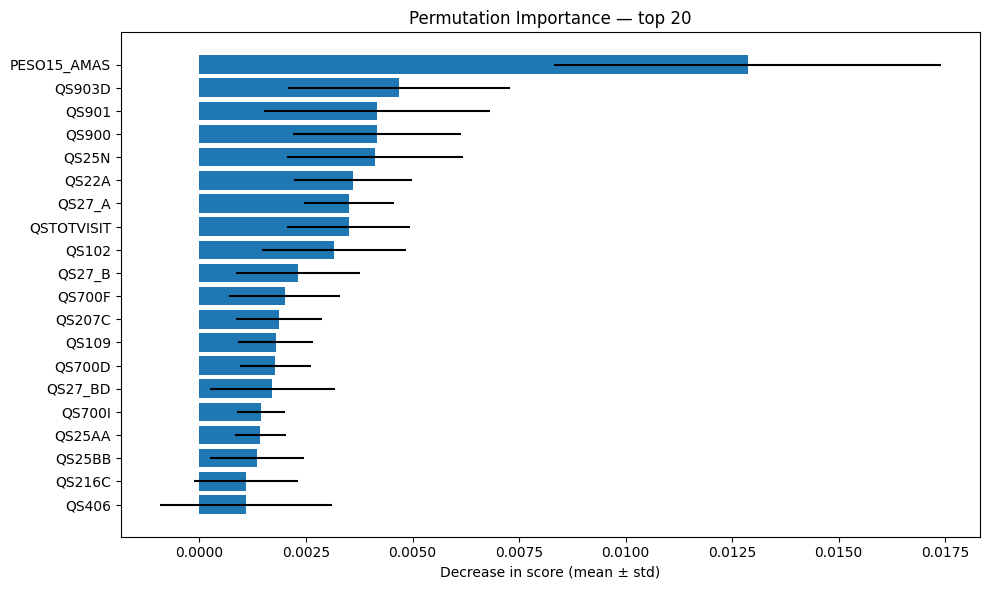

In [41]:
plot_perm_importance_bar(RANK_Modulo1640_CSALUD01_2024_M_clear, top_n=20, title="Permutation Importance — top 20")

In [42]:
save_file(RANK_Modulo1640_CSALUD01_2024_M_clear, output_file = "RANK_Modulo1640_CSALUD01_2024_M_clear.csv")